In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sifenbeyan/superstore-dataset/Sample - Superstore.csv


In [2]:
import os
os.listdir("/kaggle/input")

['datasets']

In [3]:
import os
os.listdir("/kaggle/input/datasets")

['sifenbeyan']

In [4]:
import os
os.listdir("/kaggle/input/datasets/sifenbeyan")

['superstore-dataset']

In [5]:
import os
os.listdir("/kaggle/input/datasets/sifenbeyan/superstore-dataset")

['Sample - Superstore.csv']

    objective

This project aims to explore, clean, analyze, and visualize the Superstore dataset using Pandas. The analysis focuses on identifying trends, patterns, and business insights from sales, profit, and customer data.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(
    "/kaggle/input/datasets/sifenbeyan/superstore-dataset/Sample - Superstore.csv",
    encoding="latin1"
)

# First rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


   Load Dataset

In this step, we import the required libraries and load the Superstore dataset using Pandas.

We also specify `encoding="latin1"` to correctly read special characters in the dataset.

Finally, we display the first few rows of the dataset to understand its structure and contents.

In [7]:
# Dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

     Dataset Structure

`df.info()` shows the dataset structure, including column names, data types, and missing values. It helps us understand how the data is organized.

In [8]:
# Summary statistics
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


    Summary Statistics

`df.describe()` provides statistical summary of numerical columns, including mean, median, standard deviation, minimum, and maximum values. This helps us understand the distribution of the data.

In [9]:
# Check missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

     Missing Values

`df.isnull().sum()` shows the number of missing values in each column. This helps us identify if any data cleaning is required.

In [10]:
# Fill numerical missing values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical missing values
cat_cols = df.select_dtypes(include="object").columns
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

     Handling Missing Values

In this step, we handle missing values without removing any data.

- Numerical columns are filled using the mean.
- Categorical columns are filled using the mode.

This ensures the dataset remains complete and ready for analysis.

In [11]:
# Convert Order Date and Ship Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

    Date Conversion

In this step, we convert `Order Date` and `Ship Date` columns from object type to datetime format. This allows us to perform time-based analysis such as trends over months and years.

In [12]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

     Rechecking Missing Values

After handling missing values, we re-run `df.isnull().sum()` to confirm that all missing values have been properly filled and no null values remain in the dataset.

In [13]:
# Extract Month and Year
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year
# New feature: Profit Margin
df['Profit Margin'] = df['Profit'] / df['Sales']
df[['Order Date','Order Month','Order Year','Sales','Profit','Profit Margin']].head()

,Order Date,Order Month,Order Year,Sales,Profit,Profit Margin
0,2016-11-08,11,2016,261.9600,41.9136,0.1600
1,2016-11-08,11,2016,731.9400,219.5820,0.3000
2,2016-06-12,6,2016,14.6200,6.8714,0.4700
3,2015-10-11,10,2015,957.5775,-383.0310,-0.4000
4,2015-10-11,10,2015,22.3680,2.5164,0.1125


   Feature Engineering

In this step, we create new useful features from existing data:
- Extract Month and Year from the `Order Date` column.
- Create a new feature called Profit Margin, calculated as Profit divided by Sales.

These features help in better time-based and financial analysis.

In [14]:
# Total sales by category
df.groupby('Category')['Sales'].sum()


Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

    Sales by Category

We use `groupby()` to calculate the total sales for each product category. This helps us identify which category generates the highest revenue.

In [15]:
# Total profit by region
df.groupby('Region')['Profit'].sum()

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

   Profit by Region

We use `groupby()` to calculate the total profit for each region. This helps us compare regional performance and identify the most and least profitable areas.

In [16]:
# Top 5 customers by sales
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64

   Top 5 Customers by Sales

We group the data by customer name and calculate total sales for each customer. Then we sort the results in descending order to identify the top 5 customers who generate the highest sales.

In [17]:
# Monthly sales trend
monthly_sales = df.groupby(['Order Year','Order Month'])['Sales'].sum()
monthly_sales

Order Year  Order Month
2014        1               14236.8950
            2                4519.8920
            3               55691.0090
            4               28295.3450
            5               23648.2870
            6               34595.1276
            7               33946.3930
            8               27909.4685
            9               81777.3508
            10              31453.3930
            11              78628.7167
            12              69545.6205
2015        1               18174.0756
            2               11951.4110
            3               38726.2520
            4               34195.2085
            5               30131.6865
            6               24797.2920
            7               28765.3250
            8               36898.3322
            9               64595.9180
            10              31404.9235
            11              75972.5635
            12              74919.5212
2016        1               18542.4910
 

     Monthly Sales Trend

We group the data by Year and Month and calculate total sales. This helps us analyze how sales change over time and identify trends or seasonal patterns.

In [18]:
# Sales by category and region
pd.pivot_table(df, values='Sales', index='Category', columns='Region', aggfunc='sum')

Region,Central,East,South,West
Category,,,,
Furniture,163797.1638,208291.204,117298.684,252612.7435
Office Supplies,167026.4150,205516.055,125651.313,220853.2490
Technology,170416.3120,264973.981,148771.908,251991.8320


  Pivot Table: Sales by Category and Region

We use a pivot table to summarize total sales across different categories and regions. This helps us compare performance across multiple dimensions in a structured format.

In [19]:
# Sales by segment over time
pd.pivot_table(df, values='Sales', index='Order Year', columns='Segment', aggfunc='sum')

Segment,Consumer,Corporate,Home Office
Order Year,,,
2014,266096.8126,128434.8737,89715.8118
2015,266535.9333,128757.3069,75239.2688
2016,296863.8992,207106.3618,105235.3370
2017,331904.6999,241847.8244,159462.7309


   Pivot Table: Sales by Segment Over Time

We create a pivot table to analyze total sales by segment across different years. This helps us understand how each customer segment performs over time.

In [20]:
# Profit by sub-category
pd.pivot_table(df, values='Profit', index='Sub-Category', aggfunc='sum')

,Profit
Sub-Category,
Accessories,41936.6357
Appliances,18138.0054
Art,6527.7870
Binders,30221.7633
Bookcases,-3472.5560
Chairs,26590.1663
Copiers,55617.8249
Envelopes,6964.1767
Fasteners,949.5182


  Pivot Table: Profit by Sub-Category

We use a pivot table to calculate total profit for each sub-category. This helps us identify which product sub-categories are most and least profitable.

In [21]:
# Split dataset
sales_df = df[['Order ID','Customer Name','Sales','Profit']]
info_df = df[['Order ID','Category','Region','Order Date']]

   Data Splitting

In this step, we split the dataset into two meaningful parts:
- One focused on sales and customer information
- Another focused on product and order details

This helps in organizing data for separate analysis tasks.

In [22]:
# Merge back
merged_df = pd.merge(sales_df, info_df, on='Order ID')
merged_df.head()

,Order ID,Customer Name,Sales,Profit,Category,Region,Order Date
0,CA-2016-152156,Claire Gute,261.96,41.9136,Furniture,South,2016-11-08
1,CA-2016-152156,Claire Gute,261.96,41.9136,Furniture,South,2016-11-08
2,CA-2016-152156,Claire Gute,731.94,219.5820,Furniture,South,2016-11-08
3,CA-2016-152156,Claire Gute,731.94,219.5820,Furniture,South,2016-11-08
4,CA-2016-138688,Darrin Van Huff,14.62,6.8714,Office Supplies,West,2016-06-12


    Data Merging

After splitting the dataset, we merge the two DataFrames back using `Order ID` as the common key. This ensures that all related information is correctly combined into a single dataset.

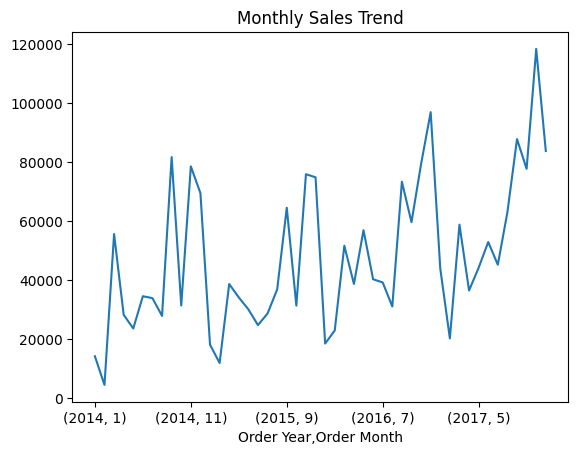

In [23]:
# Line chart: Sales trend over time
monthly_sales.plot(kind='line', title='Monthly Sales Trend')
plt.show()

  Line Chart: Sales Trend Over Time

We use a line chart to visualize how sales change over time. This helps us identify trends, growth patterns, and seasonal variations in sales performance.

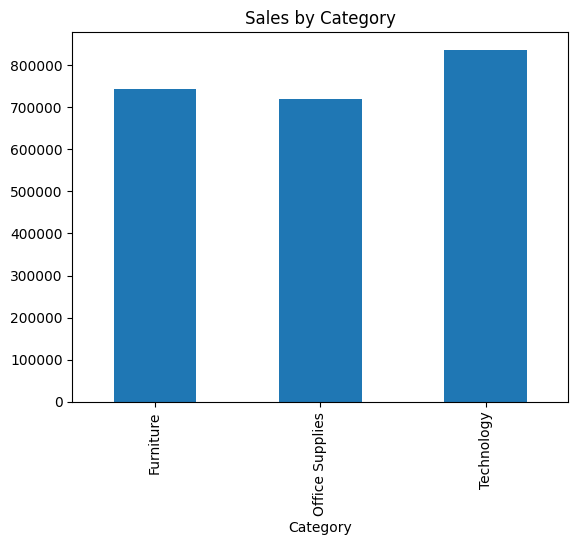

In [24]:
# Bar chart: Sales by category
df.groupby('Category')['Sales'].sum().plot(kind='bar', title='Sales by Category')
plt.show()

    Bar Chart: Sales by Category

We use a bar chart to visualize total sales for each product category. This makes it easy to compare performance across categories and identify the highest and lowest contributors to sales.

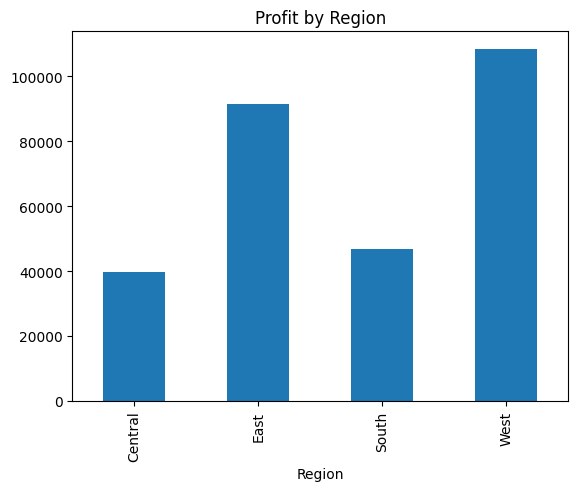

In [25]:
# Bar chart: Profit by region
df.groupby('Region')['Profit'].sum().plot(kind='bar', title='Profit by Region')
plt.show()

    Bar Chart: Profit by Region

We use a bar chart to show total profit across different regions. This helps us compare regional performance and quickly identify the most and least profitable regions.

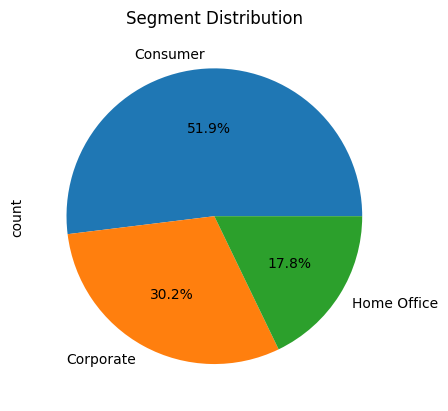

In [26]:
# Pie chart: Segment distribution
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Segment Distribution')
plt.show()

   Pie Chart: Segment Distribution

We use a pie chart to show the distribution of customers across different segments. This helps us understand the proportion of each segment in the dataset.

        Insights 

    Most Profitable Category
Technology is the most profitable category, generating the highest overall profit compared to Furniture and Office Supplies.

    Least Performing Region
The South region shows the lowest profit, indicating weaker performance compared to other regions.

    Sales vs Profit Relationship
There is a positive relationship between sales and profit, but not always proportional. Some high-sales items generate low profit due to discounts.

    Important Trends Over Time
Sales show seasonal patterns with fluctuations over months. Some periods have strong growth while others show decline, indicating demand variation over time.

      README (Superstore Data Analysis Project (Pandas))

    Project Overview
This project analyzes the Superstore dataset using Python Pandas to explore sales, profit, and customer behavior. The goal is to extract meaningful business insights through data cleaning, transformation, aggregation, and visualization.


    Dataset
- Source: Kaggle Superstore Dataset  
- File: `Sample - Superstore.csv`  
- Contains information about orders, customers, products, sales, and profit.

    Objectives
- Explore and understand dataset structure
- Clean and prepare data for analysis
- Perform feature engineering
- Analyze sales and profit trends
- Create pivot tables and visualizations
- Extract key business insights

       Tools Used
- Python
- Pandas
- NumPy
- Matplotlib

---

   Project Steps

1. Data Loading & Exploration
- Loaded dataset using Pandas
- Checked structure using `df.info()`
- Generated summary statistics using `df.describe()`

2. Data Cleaning
- Checked missing values using `isnull().sum()`
- Handled missing values using mean (numerical) and mode (categorical)
- Converted date columns to datetime format

 3. Feature Engineering
- Extracted Month and Year from Order Date
- Created Profit Margin feature

4. Data Analysis
- Sales by Category
- Profit by Region
- Top Customers by Sales
- Monthly Sales Trends

 5. Pivot Tables
- Sales by Category and Region
- Sales by Segment over time
- Profit by Sub-Category
 6. Data Visualization
- Line chart: Sales trends over time
- Bar charts: Sales by category, Profit by region
- Pie chart: Segment distribution

 Key Insights

- Most profitable category: Technology  
- Least performing region: South  
- Sales and profit are positively related but not always proportional due to discounts  
- Sales show seasonal trends over time  

Conclusion

This project demonstrates how Pandas can be used for real-world data analysis to extract business insights and support decision-making.